In [2]:
pip install mpi4py

Defaulting to user installation because normal site-packages is not writeable
  Using cached mpi4py-4.1.2-cp312-cp312-manylinux1_x86_64.manylinux_2_5_x86_64.whl.metadata (16 kB)
Using cached mpi4py-4.1.2-cp312-cp312-manylinux1_x86_64.manylinux_2_5_x86_64.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
from params import *
import population_class
from population_class import *
from population_plotter import *
from TNO_sim_lib import *
import logging
import emcee
import runprops
import param_versions

In [2]:
# Set to a runs/<objectname>/<run_file> directory (relative to this
# notebook's location, e.g. "runs/Pluto_test/000") to load run config from
# its runprops.txt. Leave as None to use the hardcoded defaults in
# emcee_walker() below instead.
RUN_DIR = None # "runs/Pluto_test/debug"

run_config = runprops.load_runprops(RUN_DIR) if RUN_DIR else None

In [3]:
def det_prob(sep, dm):
    if sep < 0.1:
        return False
    elif sep < 0.5:
        if dm > 12.5 * sep - 1.25:
            return False
    elif dm > 5:
        return False
    return True


class ObservedPopulation:
    """
    Thin wrapper so a real observed-binary csv (loaded via runprops'
    "reference_pop" field) exposes the same `.popu`/`__str__` interface
    that Pluto() and Population() provide to get_log_likelihood().
    """
    def __init__(self, popu):
        self.popu = popu

    def __str__(self):
        return f'Observed population\n Total: {len(self.popu)}\n'

In [4]:
def emcee_walker(runprops=None):
    """
    Run the emcee ensemble sampler for the moonlike-binary population fit.

    If `runprops` (e.g. the `runprops` module's `.runprops` dict) is given,
    run parameters come from it; otherwise falls back to the hardcoded
    defaults below.
    """
    if runprops is not None:
        nwalkers       = runprops.get("nwalkers", 100)
        ndim           = runprops.get("ndim", 8)
        step_count     = runprops.get("nsteps", 1000)
        burn_count     = runprops.get("nburnin", 500)
        numpy_seed     = runprops.get("numpy_seed")
        ref_pop_name   = runprops.get("reference_pop", "Pluto")
        params_version = runprops.get("params_version")
    else:
        nwalkers       = 100
        ndim           = 8 # number of params
        step_count     = 1000 # how many times we run the whole simulation
        burn_count     = 500 # iterations to do and toss before starting the real run
        numpy_seed     = None
        ref_pop_name   = "Pluto"
        params_version = None

    if params_version:
        # Locks this run to a frozen Parameters/<version>.py snapshot instead
        # of whatever params.py currently contains. population_class.py
        # resolves OrbitParamDist/InitWideParams through its own module
        # globals (from its own `from params import *`), so both namespaces
        # need patching for the swap to actually reach Population().
        param_versions.apply_params_version(params_version, [globals(), vars(population_class)])
        print(f"Using parameter model '{params_version}' from Parameters/")

    det_prob_fn = globals().get(runprops.get("det_prob_function"), det_prob) if runprops is not None else det_prob

    if numpy_seed is not None:
        np.random.seed(numpy_seed)

    if ref_pop_name == "Pluto":
        reference_pop = Pluto()
    else:
        reference_pop = ObservedPopulation(pd.read_csv(ref_pop_name))

    p0 = np.array([InitMoonParams().to_array() for _ in range(nwalkers)])
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[reference_pop, det_prob_fn])
    print(f"Burn-in: {burn_count} steps x {nwalkers} walkers")
    state = sampler.run_mcmc(p0, burn_count, progress=True)
    sampler.reset()
    print(f"Sampling: {step_count} steps x {nwalkers} walkers")
    sampler.run_mcmc(state, step_count, progress=True)
    # TODO: multimoon has functions to graph emcee results
    # TODO: verbose mode and plotting mode
    return sampler

In [5]:
def get_log_likelihood(theta, reference_pop, det_prob, verbose = False):
    """
    Log-likelihood of the observed binary population given one simulated realization.

    Combines two terms:
      1. Poisson likelihood on binary count: P(N_obs | N_det_sim)
      2. KDE likelihood on the (sep, dm) distribution of detected binaries:
         sum_i log f_sim(sep_i, dm_i) for each observed binary i

    The KDE is built from the simulated detected population and evaluated at
    each observed binary's (sep, dm). This is an unbinned likelihood, so no
    binning choices are needed.

    Parameters
    ----------
    theta : array-like, shape (ndim,)
        Flat moonlike parameter vector for one emcee walker, in MOON_PARAM_NAMES
        order (fb, ka, ae, ke, ai, ki, mdm, sdm).
    reference_pop : Population
        Real observed binaries. reference_pop.popu must have columns: sep, dm.
    det_prob : callable
        Detection probability function passed through to Population().

    Returns
    -------
    float
        Total log-likelihood. Returns -inf if the simulation produces fewer
        than 2 detected binaries (KDE undefined) while observations exist.
    """
    init_params = moon_params_from_array(theta)
    simulated_pop = Population(reference_pop.popu, init_params, det_prob)
    det = simulated_pop.popu[simulated_pop.popu['detected']].dropna(subset=['sep', 'dm'])
    ref = reference_pop.popu.dropna(subset=['sep', 'dm'])
    n_det = len(det)
    n_ref = len(ref)

    # Poisson likelihood on the binary count
    ll_count = poisson.logpmf(n_ref, mu=max(n_det, 1e-300))
    simulated_pop.ll_count = ll_count

    if verbose is True:
        print(reference_pop.__str__())
        print(simulated_pop.__str__())
        plot_sep_vs_dm(simulated_pop, reference_pop.popu)
        plot_pa_vs_sep(simulated_pop, reference_pop.popu)
        plot_pa_vs_sep(simulated_pop)
        plot_orbits(simulated_pop)

    return ll_count

In [6]:
def log_posterior(theta, reference_pop, det_prob, verbose = False):
    """
    log_prior(theta) + get_log_likelihood(theta, ...); this is what emcee
    should sample, so that walker proposals outside PARAM_BOUNDS (e.g. a
    negative ka/ae/ke/ai/ki, which crashes rng.power/rng.beta) are rejected
    via -inf instead of reaching the likelihood function at all.
    """
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + get_log_likelihood(theta, reference_pop, det_prob, verbose)

In [7]:
def run_once():
    reference_pop = Pluto()
    moon_params = InitMoonParams()
    ll_count = get_log_likelihood(moon_params.to_array(), reference_pop, det_prob, True)
    simulated_pop = Population(reference_pop.popu, moon_params.moon_params, det_prob)

no run config, running once
Reference population
 Singles: 44
 Moonlike: 456
 Wide: 0
 Total: 500
 Binary fraction: 0.912
 Log likelihood: N/A

Simulated population
 Singles: 114
 Moonlike: 386
 Wide: 0
 Total: 500
 Binary fraction: 0.772
 Log likelihood: -312.7852492563861



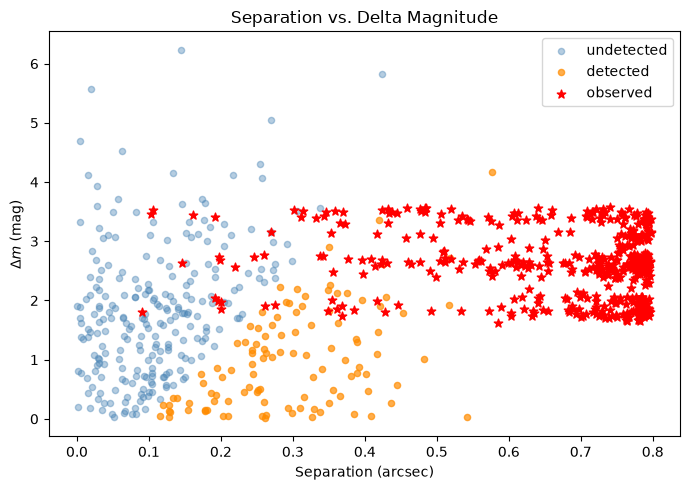

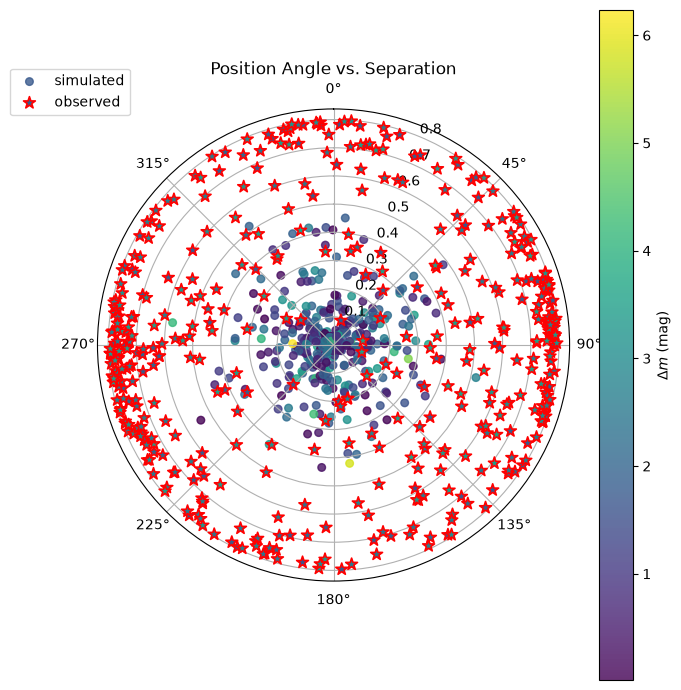

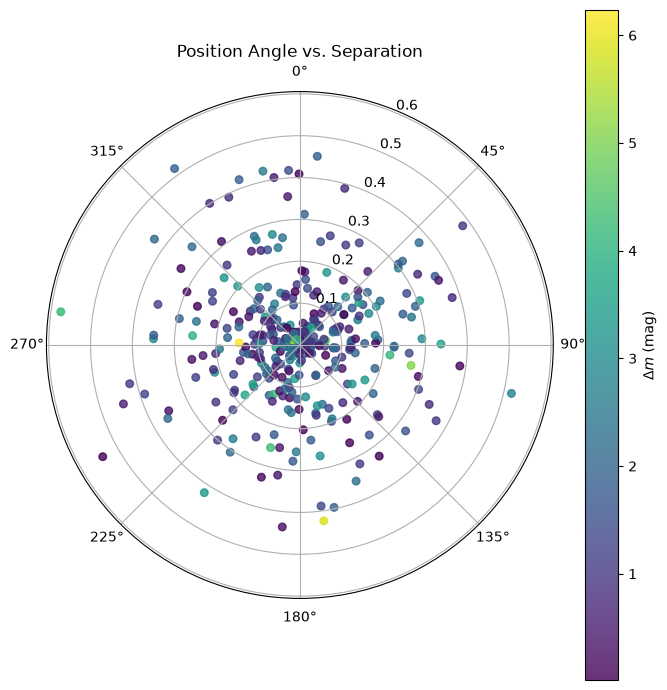

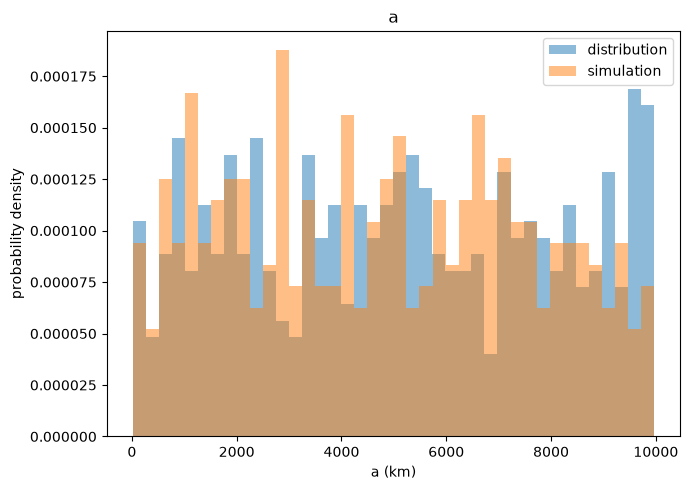

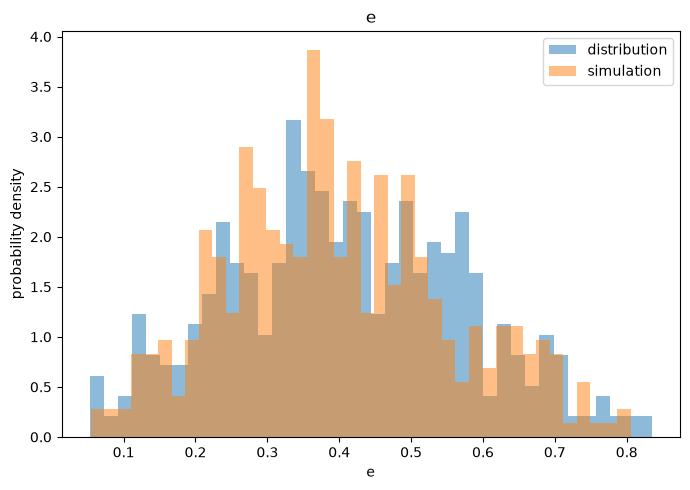

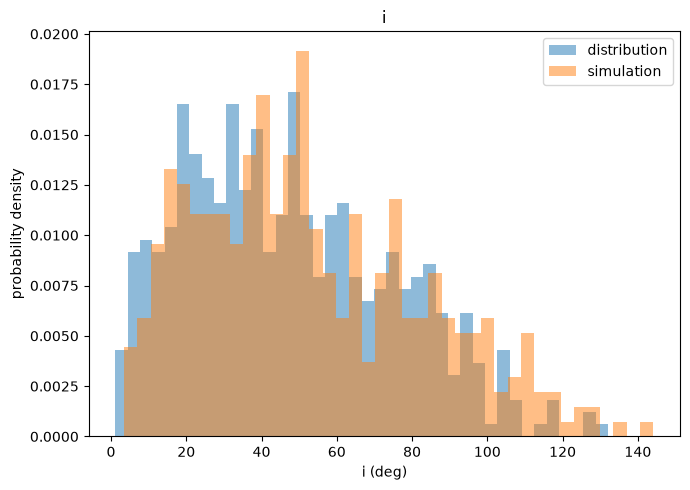

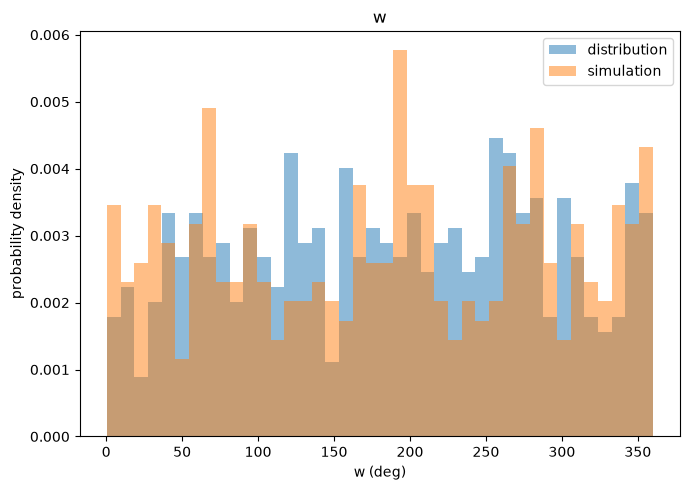

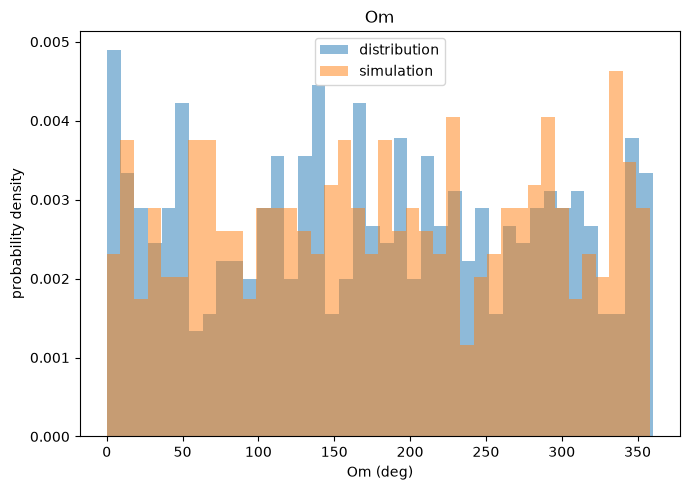

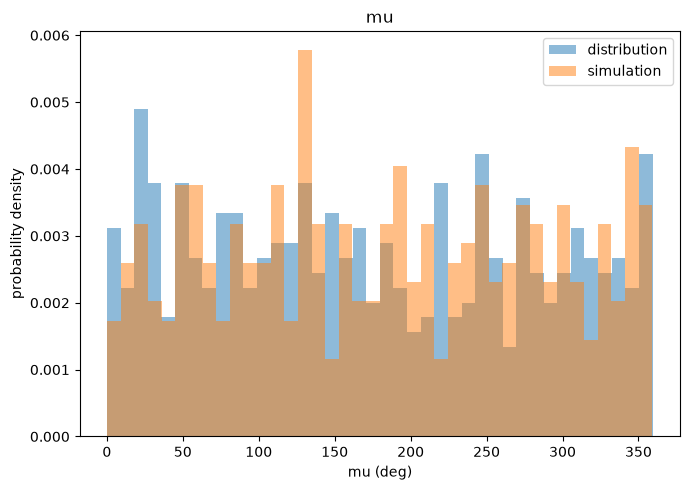

In [8]:
if __name__ == '__main__':
    if run_config is not None:
        print("run config going!")
        emcee_walker(run_config)
    else:
        print("no run config, running once")
        run_once()